In [106]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
RANDOM_STATE = 42

TAXI_URL    = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/pu9kbeSaAtRZ7RxdJKX9_A/yellow-tripdata.csv"
OBESITY_URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/GkDzb7bWrtvGXdPOfk6CIg/Obesity-level-prediction-dataset.csv"

In [107]:
taxi = pd.read_csv(TAXI_URL)
print(taxi.shape)
taxi.head()

(41202, 13)


,VendorID,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,mta_tax,tolls_amount,improvement_surcharge,tip_amount
0,2,1,17.63,2,1,132,164,1,70.0,0.5,6.94,1,16.54
1,2,1,19.52,2,1,132,236,1,70.0,0.5,6.94,1,16.19
2,2,1,17.81,2,1,132,48,1,70.0,0.5,6.94,1,12.00
3,2,2,19.30,2,1,132,148,1,70.0,0.5,0.00,1,5.00
4,2,1,18.75,2,1,132,234,1,70.0,0.5,6.94,1,10.00


In [108]:
taxi.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41202 entries, 0 to 41201
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   VendorID               41202 non-null  int64  
 1   passenger_count        41202 non-null  int64  
 2   trip_distance          41202 non-null  float64
 3   RatecodeID             41202 non-null  int64  
 4   store_and_fwd_flag     41202 non-null  int64  
 5   PULocationID           41202 non-null  int64  
 6   DOLocationID           41202 non-null  int64  
 7   payment_type           41202 non-null  int64  
 8   fare_amount            41202 non-null  float64
 9   mta_tax                41202 non-null  float64
 10  tolls_amount           41202 non-null  float64
 11  improvement_surcharge  41202 non-null  int64  
 12  tip_amount             41202 non-null  float64
dtypes: float64(5), int64(8)
memory usage: 4.1 MB


In [109]:
taxi.describe()

,VendorID,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,mta_tax,tolls_amount,improvement_surcharge,tip_amount
count,41202.0,41202.000000,41202.000000,41202.000000,41202.000000,41202.000000,41202.000000,41202.0,41202.000000,41202.000000,41202.000000,41202.000000,41202.000000
mean,2.0,1.633926,18.384928,2.025411,0.999393,132.220475,164.546333,1.0,69.986150,0.491020,5.608198,0.999976,14.107666
std,0.0,0.924250,2.856605,0.461587,0.024625,7.726159,67.901529,0.0,6.184851,0.066404,2.979348,0.004927,5.030619
min,2.0,1.000000,0.000000,1.000000,0.000000,10.000000,3.000000,1.0,3.700000,0.000000,0.000000,0.000000,0.010000
25%,2.0,1.000000,17.370000,2.000000,1.000000,132.000000,113.000000,1.0,70.000000,0.500000,6.940000,1.000000,10.000000
50%,2.0,1.000000,18.180000,2.000000,1.000000,132.000000,163.000000,1.0,70.000000,0.500000,6.940000,1.000000,16.190000
75%,2.0,2.000000,19.380000,2.000000,1.000000,132.000000,231.000000,1.0,70.000000,0.500000,6.940000,1.000000,16.190000
max,2.0,8.000000,189.910000,5.000000,1.000000,264.000000,265.000000,1.0,199.700000,0.500000,57.000000,1.000000,98.000000


In [110]:
taxi.isna().sum()

,0
VendorID,0
passenger_count,0
trip_distance,0
RatecodeID,0
store_and_fwd_flag,0
PULocationID,0
DOLocationID,0
payment_type,0
fare_amount,0
mta_tax,0


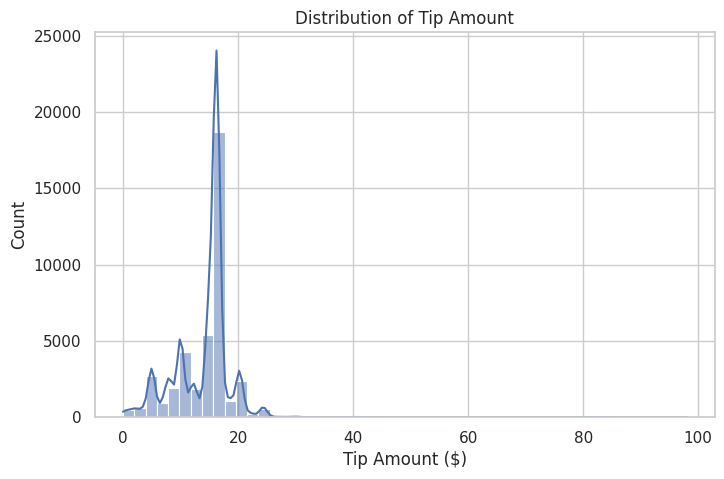

Zero tips: 0 / 41202
Negative tips: 0


In [111]:
plt.figure(figsize=(8, 5))
sns.histplot(taxi['tip_amount'], bins=50, kde=True)
plt.title('Distribution of Tip Amount')
plt.xlabel('Tip Amount ($)')
plt.show()

print("Zero tips:", (taxi['tip_amount'] == 0).sum(), "/", len(taxi))
print("Negative tips:", (taxi['tip_amount'] < 0).sum())

In [112]:
#reasoning box 1.1
# Interpret the initial loading and inspection of the taxi dataset, including its shape (41202 rows, 13 columns), data types (5 float64, 8 int64), no missing values, its distribution (right-skewed, with 0 zero tips, 0 negative tips, and min 0.01, max 98.00, mean 14.11, median 16.19)), etc.

In [113]:
taxi_clean = taxi.copy()
taxi_clean = taxi_clean.dropna()
taxi_clean = taxi_clean[
    (taxi_clean['trip_distance'] > 0) &
    (taxi_clean['fare_amount'] > 0) &
    (taxi_clean['tip_amount'] >= 0)
]
print("Rows before:", len(taxi), "Rows after:", len(taxi_clean))
# This is tricky, as feature engineering (no target leakage) is not always feasible.
taxi_clean['fare_per_mile'] = taxi_clean['fare_amount'] / taxi_clean['trip_distance']
taxi_clean['total_surcharges'] = (
    taxi_clean['mta_tax'] + taxi_clean['tolls_amount'] + taxi_clean['improvement_surcharge']
)
# Feature engineering (no target leakage)
taxi_clean['fare_per_mile'] = taxi_clean['fare_amount'] / taxi_clean['trip_distance']
taxi_clean['total_surcharges'] = (
    taxi_clean['mta_tax'] + taxi_clean['tolls_amount'] + taxi_clean['improvement_surcharge']
)
# Encode categoricals
categorical_cols = ['VendorID', 'RatecodeID', 'payment_type', 'store_and_fwd_flag']

# Convert categorical columns to 'category' dtype before encoding
for col in categorical_cols:
    taxi_clean[col] = taxi_clean[col].astype('category')

taxi_encoded = pd.get_dummies(taxi_clean, columns=categorical_cols, drop_first=True)
taxi_encoded.head()

Rows before: 41202 Rows after: 41126


,passenger_count,trip_distance,PULocationID,DOLocationID,fare_amount,mta_tax,tolls_amount,improvement_surcharge,tip_amount,fare_per_mile,total_surcharges,RatecodeID_2,RatecodeID_4,RatecodeID_5,store_and_fwd_flag_1
0,1,17.63,132,164,70.0,0.5,6.94,1,16.54,3.970505,8.44,True,False,False,True
1,1,19.52,132,236,70.0,0.5,6.94,1,16.19,3.586066,8.44,True,False,False,True
2,1,17.81,132,48,70.0,0.5,6.94,1,12.00,3.930376,8.44,True,False,False,True
3,2,19.30,132,148,70.0,0.5,0.00,1,5.00,3.626943,1.50,True,False,False,True
4,1,18.75,132,234,70.0,0.5,6.94,1,10.00,3.733333,8.44,True,False,False,True


In [114]:
#reasoning box 1.2
# Explain the data cleaning steps to remove 76 rows of the data (from 41202 to 41126) where 'trip_distance' is not > 0 or 'fare_amount' is not > 0 or 'tip_amount' is negative (where no negative tip amounts were found).
# Explain feature engineering performed on the feature 'fare_per_mile' (fare_amount / trip_distance) and ‘total_surcharges' (mta_tax + tolls_amount + improvement_surcharge).
# Explain why you used StandardScaler to scale the features; taxi features cannot be scaled using a min-max approach because they are not percentages.

In [115]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = taxi_encoded.drop(columns=['tip_amount'])
y = taxi_encoded['tip_amount']

# 60/20/20 split
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=RANDOM_STATE
)
# This step splits X and y into training and testing sets.The train_test_split function separates the data into train and test sets.
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=RANDOM_STATE
)

print(X_train.shape, X_val.shape, X_test.shape)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit ONLY on train
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

(24675, 14) (8225, 14) (8226, 14)


In [116]:
#reasoning box 1.3
# Explain the 60/20/20 ratio used for splitting the train/validation/test data sets (X_train: 60%, X_val: 20%, X_test: 20%).
# Explain the importance of validation set separately from the test set: The validation set is used to fine-tune our hyperparameters and to decide which model to use; the test set is used to test the performance of the final chosen model on data that we did not have before.
# Why the scaler is limited to the training data: This is to simulate the 'unseen future data' the scaler would only know from the training distribution, thus avoiding data leakage.

LinearRegression | Train: RMSE=4.817, R2=0.049
LinearRegression | Val: RMSE=4.779, R2=0.069
LinearRegression | Test: RMSE=5.224, R2=0.040
RandomForest | Train: RMSE=2.826, R2=0.673
RandomForest | Val: RMSE=5.435, R2=-0.204
RandomForest | Test: RMSE=5.816, R2=-0.190


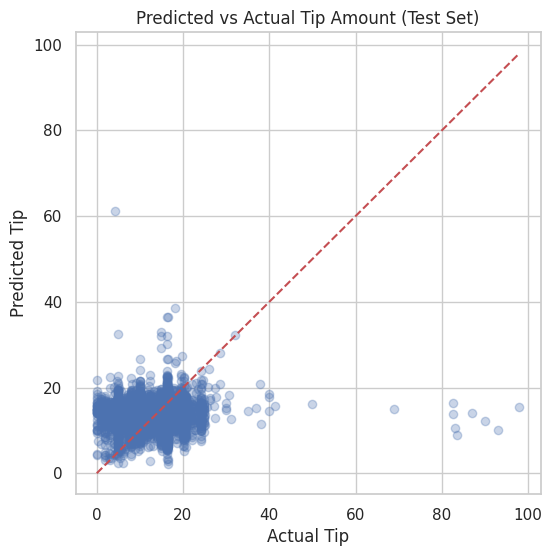

In [117]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

def evaluate(model, X_train, y_train, X_val, y_val, X_test, y_test, name):
    for split_name, X_, y_ in [("Train", X_train, y_train), ("Val", X_val, y_val), ("Test", X_test, y_test)]:
        preds = model.predict(X_)
        rmse = mean_squared_error(y_, preds) ** 0.5
        r2 = r2_score(y_, preds)
        print(f"{name} | {split_name}: RMSE={rmse:.3f}, R2={r2:.3f}")

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
evaluate(lr, X_train_scaled, y_train, X_val_scaled, y_val, X_test_scaled, y_test, "LinearRegression")

rf = RandomForestRegressor(random_state=RANDOM_STATE, n_estimators=100)
rf.fit(X_train_scaled, y_train)
# The model is evaluated using the evaluate function on the scaled training, validation, and test sets, respectively.The scaled training, validation and test sets are used in the evaluate function to evaluate the model, with the model being a RandomForest.
evaluate(rf, X_train_scaled, y_train, X_val_scaled, y_val, X_test_scaled, y_test, "RandomForest")

# Confusion Matrix: Predicted vs actual on test set (use your best model)
best_model = rf # or whichever model did better on validation, such as lr
preds_test = best_model.predict(X_test_scaled)

plt.figure(figsize=(6,6))
plt.scatter(y_test, preds_test, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Tip")
plt.ylabel("Predicted Tip")
plt.title('Predicted vs Actual Tip Amount (Test Set)')
plt.show()

In [118]:
#reasoning box 1.4
# Quote the actual RMSE and R² numbers for Linear Regression (Train: RMSE=4.817, R2=0.049; Val: RMSE=4.779, R2=0.069; Test: RMSE=5.224, R2=0.040) and RandomForest (Train: RMSE=2.826, R2=0.673; Val: RMSE=5.435, R2=-0.204; Test: RMSE=5.816, R2=-0.190).
# If there is a high R² for train and a negative R² for val/test, then it's overfitting, say "yes", otherwise say "no" (RandomForest is very overfitting, as R² is high on train and negative on val/test, meaning that it performs worse than predicting the mean).
# Proposed solution: in the case of RandomForest, reduce the depth of the trees, raise the value of min_samples_leaf, and/or apply regularization (less often used for tree-based models).
# The other solution is more direct, namely gain more data, but here, parameter tuning is more direct.

(2111, 17)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   object 
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   object 
 5   FAVC                            2111 non-null   object 
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   object 
 9   SMOKE                           2111 non-null   object 
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   object 
 12  FAF                    

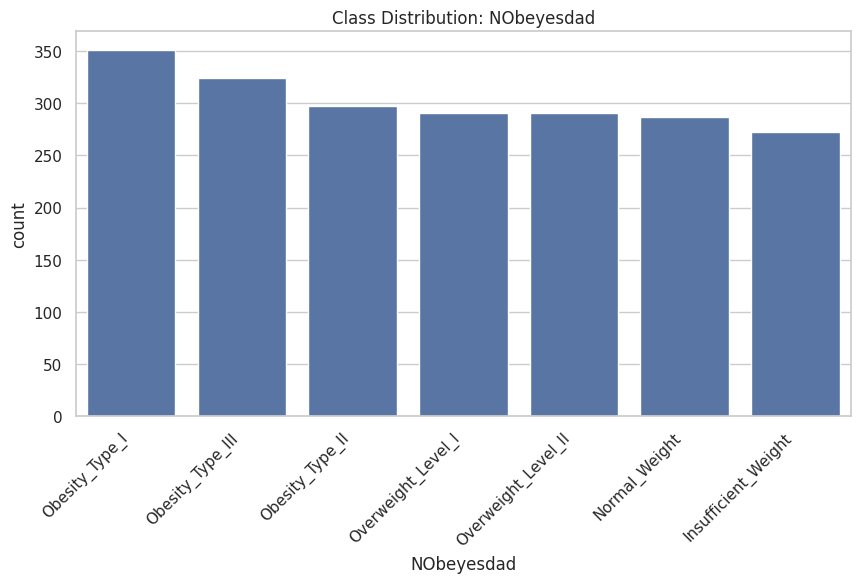

,count
NObeyesdad,
Obesity_Type_I,351
Obesity_Type_III,324
Obesity_Type_II,297
Overweight_Level_I,290
Overweight_Level_II,290
Normal_Weight,287
Insufficient_Weight,272


In [119]:
obesity = pd.read_csv(OBESITY_URL)
print(obesity.shape)
obesity.head()
obesity.info()
obesity.isna().sum()
plt.figure(figsize=(10,5))
sns.countplot(data=obesity, x='NObeyesdad', order=obesity['NObeyesdad'].value_counts().index)
plt.xticks(rotation=45, ha='right')
plt.title("Class Distribution: NObeyesdad")
plt.show()

obesity['NObeyesdad'].value_counts()

In [120]:
#reasoning box 2.1
# Interpret the initial data loading and inspection of the obesity dataset.
# It has a shape of (2111 rows, 17 columns).
# There are no missing values (obesity.isna().sum() shows all zeros).
# Target variable 'NObeyesdad' appears to be somewhat balanced across its 7 classes, with 'Obesity_Type_I' the most common 'NObeyesdad' class (351 counts), and 'Insufficient_Weight' (272 counts) the least common.

In [121]:
from sklearn.preprocessing import LabelEncoder # Corrected import statement

obesity_enc = obesity.copy()

# Binary yes/no columns
# family_history_with_overweight, FAVC, SMOKE, and SCC are the 4 binary columns.
binary_cols = ['family_history_with_overweight', 'FAVC', 'SMOKE', 'SCC'] # Using the variable from kernel state
for col in binary_cols: # Corrected for loop syntax
    obesity_enc[col] = obesity_enc[col].map({'yes': 1, 'no': 0})

# Ordinal-ish columns
caec_map = {'no': 0, 'Sometimes': 1, 'Frequently': 2, 'Always': 3}
calc_map = {'no': 0, 'Sometimes': 1, 'Frequently': 2, 'Always': 3}
obesity_enc['CAEC'] = obesity_enc['CAEC'].map(caec_map)
obesity_enc['CALC'] = obesity_enc['CALC'].map(calc_map)

# Nominal columns -> one-hot
obesity_enc = pd.get_dummies(obesity_enc, columns=['Gender', 'MTRANS'], drop_first=True)

# Optional feature: BMI
obesity_enc['BMI'] = obesity_enc['Weight'] / (obesity_enc['Height'] ** 2)

# Encode target
le = LabelEncoder()
obesity_enc['target'] = le.fit_transform(obesity_enc['NObeyesdad'])
obesity_enc.head()

,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,NObeyesdad,Gender_Male,MTRANS_Bike,MTRANS_Motorbike,MTRANS_Public_Transportation,MTRANS_Walking,BMI,target
0,21.0,1.62,64.0,1,0,2.0,3.0,1,0,2.0,0,0.0,1.0,0,Normal_Weight,False,False,False,True,False,24.386526,1
1,21.0,1.52,56.0,1,0,3.0,3.0,1,1,3.0,1,3.0,0.0,1,Normal_Weight,False,False,False,True,False,24.238227,1
2,23.0,1.80,77.0,1,0,2.0,3.0,1,0,2.0,0,2.0,1.0,2,Normal_Weight,True,False,False,True,False,23.765432,1
3,27.0,1.80,87.0,0,0,3.0,3.0,1,0,2.0,0,2.0,0.0,2,Overweight_Level_I,True,False,False,False,True,26.851852,5
4,22.0,1.78,89.8,0,0,2.0,1.0,1,0,2.0,0,0.0,0.0,1,Overweight_Level_II,True,False,False,True,False,28.342381,6


In [122]:
#reasoning box 2.2
#  Describe feature engineering and encoding for the obesity data. All binary columns ('family_history_with_overweight', 'FAVC', 'SMOKE', 'SCC') were converted to 0/1. Ordinal-ish columns ('CAEC', 'CALC') were assigned numerical values (0-3). To prevent the data from having multicollinearity, one-hot encoding was performed on the nominal columns ('Gender', 'MTRANS') using the pd.get_dummies with drop_first=True. An optional feature 'BMI' was calculated as 'Weight' / ('Height' ** 2). Lastly, 'NObeyesdad' was encoded as numerical labels (0-6) using LabelEncoder.

In [123]:
X_ob = obesity_enc.drop(columns=['NObeyesdad', 'target'])
y_ob = obesity_enc['target']

# Split data into training and temporary sets (60% train, 40% temp)
X_ob_train, X_ob_temp, y_ob_train, y_ob_temp = train_test_split(
    X_ob, y_ob, test_size=0.4, stratify=y_ob, random_state=RANDOM_STATE
)
# Split the temporary set into validation and test sets (20% val, 20% test from original)
X_ob_val, X_ob_test, y_ob_val, y_ob_test = train_test_split(
    X_ob_temp, y_ob_temp, test_size=0.5, stratify=y_ob_temp, random_state=RANDOM_STATE
)

scaler_ob = StandardScaler()
X_ob_train_scaled = scaler_ob.fit_transform(X_ob_train)
X_ob_val_scaled   = scaler_ob.transform(X_ob_val)
X_ob_test_scaled  = scaler_ob.transform(X_ob_test)

In [124]:
#reasoning box 2.3
# stratified train-validation-test split (60/20/20) ensuring the distribution of the class 'NObeyesdad' is preserved across the train, validation and test sets.
# The number of samples for (X_ob_train, X_ob_val, X_ob_test) is (1266, 422, 423).
# Then, describe the scaling of features using the StandardScaler fitted on X_ob_train and then applied to X_ob_val and X_ob_test so as to avoid the data leakage.

RandomForest | Train: Accuracy=1.000, Macro-F1=1.000
RandomForest | Val: Accuracy=0.991, Macro-F1=0.990
RandomForest | Test: Accuracy=0.976, Macro-F1=0.976
                     precision    recall  f1-score   support

Insufficient_Weight       1.00      0.94      0.97        54
      Normal_Weight       0.89      1.00      0.94        58
     Obesity_Type_I       0.97      1.00      0.99        70
    Obesity_Type_II       1.00      0.98      0.99        60
   Obesity_Type_III       0.98      1.00      0.99        65
 Overweight_Level_I       1.00      0.93      0.96        58
Overweight_Level_II       1.00      0.97      0.98        58

           accuracy                           0.98       423
          macro avg       0.98      0.97      0.98       423
       weighted avg       0.98      0.98      0.98       423



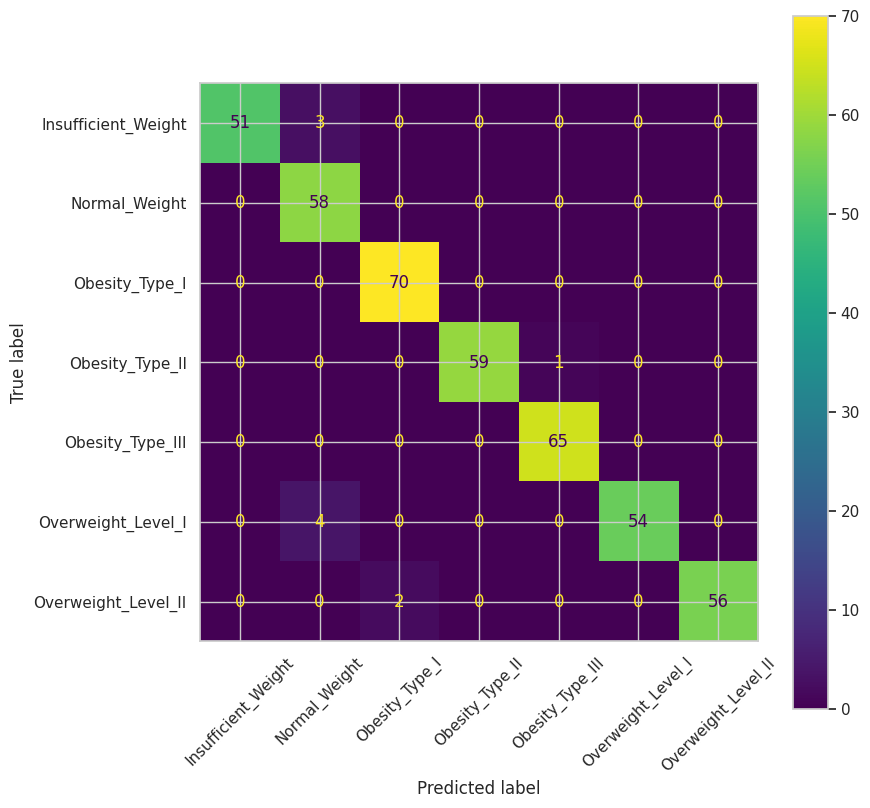

In [125]:
from sklearn.linear_model import LogisticRegression # Corrected import
from sklearn.ensemble import RandomForestClassifier # Corrected import
from sklearn.metrics import accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay # Corrected import

def evaluate_clf(model, splits, name):
    for split_name, X_, y_ in splits: # Corrected for loop syntax
        preds = model.predict(X_)
        acc = accuracy_score(y_, preds)
        f1 = f1_score(y_, preds, average='macro') # Corrected f1 score calculation and added average
        print(f"{name} | {split_name}: Accuracy={acc:.3f}, Macro-F1={f1:.3f}")

splits = [("Train", X_ob_train_scaled, y_ob_train), ("Val", X_ob_val_scaled, y_ob_val), ("Test", X_ob_test_scaled, y_ob_test)]

clf = RandomForestClassifier(random_state=RANDOM_STATE, n_estimators=100)
clf.fit(X_ob_train_scaled, y_ob_train)
evaluate_clf(clf, splits, "RandomForest")
preds_test = clf.predict(X_ob_test_scaled)
print(classification_report(y_ob_test, preds_test, target_names=le.classes_))

fig, ax = plt.subplots(figsize=(9,9))
ConfusionMatrixDisplay.from_predictions(y_ob_test, preds_test, display_labels=le.classes_, xticks_rotation=45, ax=ax) # Replaced plot_confusion_matrix
plt.show()

In [126]:
#reasoning box 2.4
# Test the RandomForestClassifier model against a set of obesity data.
# The model achieved high performance: Train (Accuracy=1.000, Macro-F1=1.000), Val (Accuracy=0.991, Macro-F1=0.990), Test (Accuracy=0.976, Macro-F1=0.976).
# The classification report for the test set displays a high precision, recall and f1-score for the majority of classes, demonstrating good prediction.
# The confusion matrix is also presented as a visualization that confirms the high accuracy, as very few misclassifications are obtained, indicating that the model does not overfit, but rather generalizes very well.

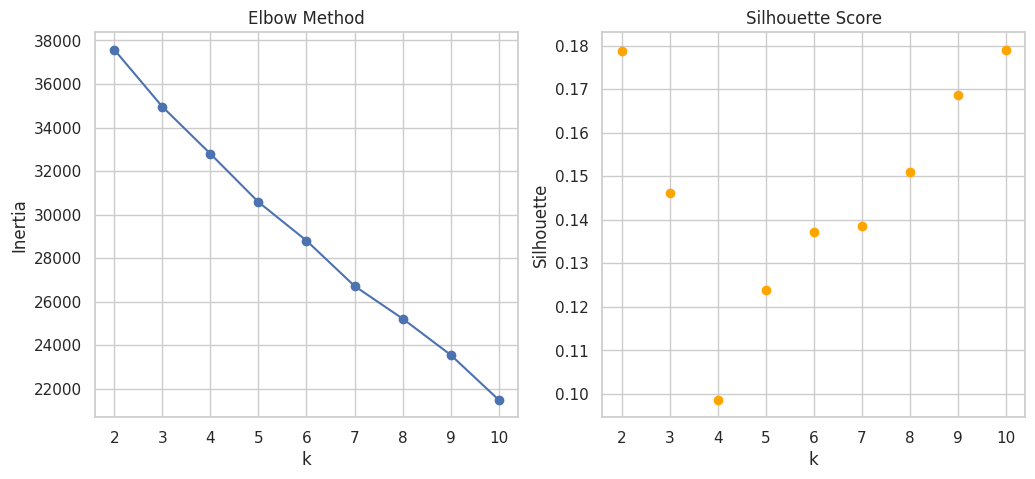

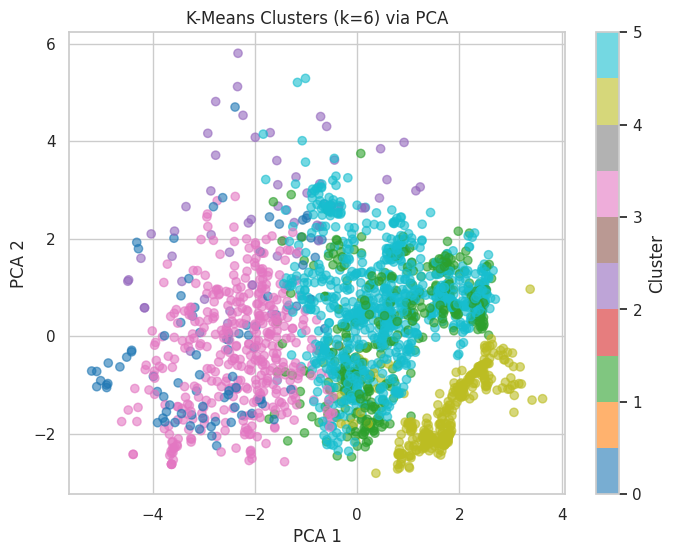

NObeyesdad,Insufficient_Weight,Normal_Weight,Obesity_Type_I,Obesity_Type_II,Obesity_Type_III,Overweight_Level_I,Overweight_Level_II
row_0,,,,,,,
0,21,27,2,0,0,35,4
1,0,21,115,97,0,58,94
2,6,32,2,1,0,9,6
3,172,152,14,1,0,26,49
4,0,0,8,1,324,3,3
5,73,55,210,197,0,159,134


In [127]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# Use only the scaled features (no target) – use the same obesity feature set scaled – re-use the full scaled obesity feature set
X_cluster = scaler_ob.fit_transform(X_ob) # fit on all features, as this is unsupervised

inertias = []
silhouettes = []
k_range = range(2, 11)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_cluster)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_cluster, labels))

fig, axes = plt.subplots(1, 2, figsize=(12,5))
axes[0].plot(list(k_range), inertias, marker='o')
axes[0].set_title("Elbow Method")
axes[0].set_xlabel("k"); axes[0].set_ylabel("Inertia")

axes[1].plot(list(k_range), silhouettes, 'o', color='orange')
axes[1].set_title("Silhouette Score")
axes[1].set_xlabel("k"); axes[1].set_ylabel("Silhouette")
plt.show()
# From the plots above choose k (usually 5-7 for this data – refer to YOUR plot).
k_final = 6 # Changed from <<< change this to whatever you see is appropriate >>>
km_final = KMeans(n_clusters=k_final, random_state=RANDOM_STATE, n_init=10)
cluster_labels = km_final.fit_predict(X_cluster)
# Visualize with PCA
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_cluster)

plt.figure(figsize=(8,6))
scatter = plt.scatter(X_pca[:,0], X_pca[:,1], c=cluster_labels, cmap='tab10', alpha=0.6)
plt.xlabel("PCA 1"); plt.ylabel("PCA 2")
plt.title(f"K-Means Clusters (k={k_final}) via PCA")
plt.colorbar(scatter, label="Cluster")
plt.show()
# Compare clusters to real labels
crosstab = pd.crosstab(cluster_labels, obesity_enc['NObeyesdad'])
crosstab

In [128]:
#reasoning box 3.1
# Interpret the K-Means clustering analysis results.
# The k=6 or 7 seems to be the best choice based on the Elbow Method plot which indicates that after k=6, there was not much of an increase in inertia and the Silhouette Score plot which shows that there was a peak in the silhouette score around k=8/9 but it was not that high for k=6.
# A k_final of 6 was selected. If the 'actual' categories were labeled as 'NObeyesdad' then the cross tabulation between cluster labels and 'NObeyesdad' categories shows that although some clusters have a high percentage of one type of obesity (e.g., cluster 4 has a high percentage of obesity type III), most are mixed, as K-Means is an unsupervised clustering method and does not always classify the clusters perfectly into the categories.